# Sub-nodes sweep (simul): per-network and per-node samples vs. test 1-R2

Loads results from the sub-node sweeps under `datalimits4simul_nozscore/`:

- `runs_datalimits_simul_msg_nodes5/`  (5 nodes kept)
- `runs_datalimits_simul_msg_nodes20/` (full 20-node graph)
- `runs_datalimits_simul_msg_nodes10/` and `runs_datalimits_simul_msg_nodes15/` are commented out for now.

Unlike the `datalimits4dyn_nozscore` reference notebook, here we do **not**
average across different `msg_config` variants — each `msg_config` keeps its
own curves (faceted view).

**Plots (each faceted by `adj_type` × `msg_config`):**
1. x = total network samples = `num_nodes_keep × num_train_samples`,
   y = single-step test `1 - R²`.
2. x = per-node samples = `num_train_samples`,
   y = single-step test `1 - R²`.

In [1]:
import os, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / 'Hungarianchickenpox' / 'datalimits4simul_nozscore',
]
BASE_DIR = None
for cand in _CANDIDATES:
    if (cand / 'runs_datalimits_simul_msg_nodes20').is_dir():
        BASE_DIR = cand.resolve()
        break
if BASE_DIR is None:
    raise FileNotFoundError('Could not locate datalimits4simul_nozscore directory from current working directory.')
PROJECT_DIR = BASE_DIR.parent
TS_CSV = PROJECT_DIR / 'hungary_chickenpox_reordered_trimmed.csv'
TARGET_MSG_CONFIG = 'rate_x'
print('Base dir:', BASE_DIR)
print('Project dir:', PROJECT_DIR)
print('TS csv:', TS_CSV)

# Map num_nodes_keep -> (runs dir, allowed num_train_samples or None for all)
DIR_SPECS = {
    4:  ('runs_datalimits_simul_msg_nodes4', None),
    5:  ('runs_datalimits_simul_msg_nodes5', None),
    6:  ('runs_datalimits_simul_msg_nodes6', None),
    7:  ('runs_datalimits_simul_msg_nodes7', None),
    8:  ('runs_datalimits_simul_msg_nodes8', None),
    9:  ('runs_datalimits_simul_msg_nodes9', None),
    10: ('runs_datalimits_simul_msg_nodes10', None),
    11: ('runs_datalimits_simul_msg_nodes11', None),
    12: ('runs_datalimits_simul_msg_nodes12', None),
    13: ('runs_datalimits_simul_msg_nodes13', None),
    14: ('runs_datalimits_simul_msg_nodes14', None),
    15: ('runs_datalimits_simul_msg_nodes15', None),
    16: ('runs_datalimits_simul_msg_nodes16', None),
    17: ('runs_datalimits_simul_msg_nodes17', None),
    18: ('runs_datalimits_simul_msg_nodes18', None),
    19: ('runs_datalimits_simul_msg_nodes19', None),
    20: ('runs_datalimits_simul_msg_nodes20', None),
}

SEEDS_TO_KEEP = None
for n, (sub, _) in DIR_SPECS.items():
    p = BASE_DIR / sub
    print(f'  N={n:>2}: {sub} ({"exists" if p.is_dir() else "MISSING"})')


Base dir: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/datalimits4simul_nozscore
Project dir: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox
TS csv: /DATA/sunyiting/ckpx_hungary/Hungarianchickenpox/hungary_chickenpox_reordered_trimmed.csv
  N= 4: runs_datalimits_simul_msg_nodes4 (exists)
  N= 5: runs_datalimits_simul_msg_nodes5 (exists)
  N= 6: runs_datalimits_simul_msg_nodes6 (exists)
  N= 7: runs_datalimits_simul_msg_nodes7 (exists)
  N= 8: runs_datalimits_simul_msg_nodes8 (exists)
  N= 9: runs_datalimits_simul_msg_nodes9 (exists)
  N=10: runs_datalimits_simul_msg_nodes10 (exists)
  N=11: runs_datalimits_simul_msg_nodes11 (exists)
  N=12: runs_datalimits_simul_msg_nodes12 (exists)
  N=13: runs_datalimits_simul_msg_nodes13 (exists)
  N=14: runs_datalimits_simul_msg_nodes14 (exists)
  N=15: runs_datalimits_simul_msg_nodes15 (exists)
  N=16: runs_datalimits_simul_msg_nodes16 (exists)
  N=17: runs_datalimits_simul_msg_nodes17 (exists)
  N=18: runs_datalimits_simul_msg_nodes18 (exis

In [2]:
# Run-name pattern (new format): run{seed}_{msg}_lam{lam}_{zscore}_{smooth}_tau{tau}_n{num_train_samples}
# Per-run metrics resolution order:
#   1. results.json                  (compact summary written by the latest training script)
#   2. loss_curves.pkl               (per-epoch lists; only useful if metrics_every fired)
#   3. final_model.pt                (torch payload; always has best-state final_*_metrics)
import pickle

PATTERN = re.compile(
    r'^run(?P<seed>\d+)_'
    r'(?P<msg>rate_x)_'
    r'lam(?P<lam>[0-9.]+)_'
    r'(?P<zscore>nozscore|zscore)_'
    r'(?P<smooth>gaussian|none)_'
    r'tau(?P<tau>[0-9.]+)_'
    r'n(?P<n>\d+)$'
)

def _last_finite(seq):
    arr = np.asarray(seq, dtype=float) if seq is not None else np.array([])
    if arr.size == 0:
        return np.nan
    finite = arr[np.isfinite(arr)]
    return float(finite[-1]) if finite.size else np.nan

def load_run_metrics(run_dir):
    """Return (test_r2, test_mse, source) or (nan, nan, None) if nothing usable."""
    rj = os.path.join(run_dir, 'results.json')
    if os.path.isfile(rj):
        try:
            with open(rj) as f:
                res = json.load(f)
            test = res.get('test', {}) or {}
            r2 = test.get('r2')
            mse = test.get('mse')
            if r2 is not None and np.isfinite(float(r2)):
                return float(r2), float(mse) if mse is not None else np.nan, 'results.json'
        except Exception as e:
            print(f'[warn] failed to read {rj}: {e}')

    lc_path = os.path.join(run_dir, 'loss_curves.pkl')
    if os.path.isfile(lc_path):
        try:
            with open(lc_path, 'rb') as f:
                lc = pickle.load(f)
            r2 = _last_finite(lc.get('test_overall_r2'))
            mse = _last_finite(lc.get('test_mse'))
            if np.isfinite(r2):
                return r2, mse, 'loss_curves.pkl'
        except Exception as e:
            print(f'[warn] failed to read {lc_path}: {e}')

    fm_path = os.path.join(run_dir, 'final_model.pt')
    if os.path.isfile(fm_path):
        try:
            import torch
            payload = torch.load(fm_path, map_location='cpu', weights_only=False)
            tm = payload.get('test_metrics', {}) or {}
            r2 = tm.get('overall_r2')
            mse = payload.get('test_mse')
            if r2 is not None and np.isfinite(float(r2)):
                return float(r2), float(mse) if mse is not None else np.nan, 'final_model.pt'
        except Exception as e:
            print(f'[warn] failed to read {fm_path}: {e}')

    return np.nan, np.nan, None

rows = []
skipped_no_metrics = 0
source_counter = {}
for num_nodes, (sub, keep_list) in DIR_SPECS.items():
    runs_dir = BASE_DIR / sub
    if not runs_dir.is_dir():
        print(f'[skip] {runs_dir} does not exist')
        continue
    keep_set = set(keep_list) if keep_list is not None else None
    n_loaded = 0
    for entry in sorted(os.listdir(runs_dir)):
        full = runs_dir / entry
        if not full.is_dir():
            continue
        m = PATTERN.match(entry)
        if not m:
            continue
        if SEEDS_TO_KEEP is not None and int(m.group('seed')) not in SEEDS_TO_KEEP:
            continue
        n_train = int(m.group('n'))
        if keep_set is not None and n_train not in keep_set:
            continue

        test_r2, test_mse, source = load_run_metrics(full)
        if source is None or not np.isfinite(test_r2):
            skipped_no_metrics += 1
            continue
        source_counter[source] = source_counter.get(source, 0) + 1

        lam = m.group('lam')
        tau = m.group('tau')
        msg = m.group('msg')
        if msg != TARGET_MSG_CONFIG:
            continue
        rows.append({
            'run_name': entry,
            'num_nodes_keep': num_nodes,
            'seed': int(m.group('seed')),
            'adj_type': f'lam{lam}_tau{tau}',
            'lam': float(lam),
            'tau': float(tau),
            'msg_config': msg,
            'zscore': m.group('zscore'),
            'smooth': m.group('smooth'),
            'num_train_samples': n_train,
            'total_samples': num_nodes * n_train,
            'test_r2': float(test_r2),
            'one_minus_r2': float(1.0 - test_r2),
            'test_mse': float(test_mse) if np.isfinite(test_mse) else np.nan,
            'metrics_source': source,
        })
        n_loaded += 1
    print(f'  N={num_nodes:>2}: loaded {n_loaded} runs from {sub}')

if not rows:
    raise RuntimeError('No runs loaded. Check paths or run-name pattern.')

df = pd.DataFrame(rows).sort_values(['num_nodes_keep', 'num_train_samples', 'seed']).reset_index(drop=True)
df = df[df['msg_config'] == TARGET_MSG_CONFIG].copy()
print('sources used:', source_counter)
print('skipped (no usable metrics):', skipped_no_metrics)
print('adj_types:    ', sorted(df.adj_type.unique()))
print('msg_configs:  ', sorted(df.msg_config.unique()))
display(df.head())


  N= 4: loaded 600 runs from runs_datalimits_simul_msg_nodes4
  N= 5: loaded 600 runs from runs_datalimits_simul_msg_nodes5
  N= 6: loaded 600 runs from runs_datalimits_simul_msg_nodes6
  N= 7: loaded 600 runs from runs_datalimits_simul_msg_nodes7
  N= 8: loaded 600 runs from runs_datalimits_simul_msg_nodes8
  N= 9: loaded 600 runs from runs_datalimits_simul_msg_nodes9
  N=10: loaded 600 runs from runs_datalimits_simul_msg_nodes10
  N=11: loaded 600 runs from runs_datalimits_simul_msg_nodes11
  N=12: loaded 540 runs from runs_datalimits_simul_msg_nodes12
  N=13: loaded 540 runs from runs_datalimits_simul_msg_nodes13
  N=14: loaded 540 runs from runs_datalimits_simul_msg_nodes14
  N=15: loaded 540 runs from runs_datalimits_simul_msg_nodes15
  N=16: loaded 750 runs from runs_datalimits_simul_msg_nodes16
  N=17: loaded 750 runs from runs_datalimits_simul_msg_nodes17
  N=18: loaded 750 runs from runs_datalimits_simul_msg_nodes18
  N=19: loaded 750 runs from runs_datalimits_simul_msg_nodes1

,run_name,num_nodes_keep,seed,adj_type,lam,tau,msg_config,zscore,smooth,num_train_samples,total_samples,test_r2,one_minus_r2,test_mse,metrics_source
0,run1_rate_x_lam0.001_nozscore_gaussian_tau0.99_n2,4,1,lam0.001_tau0.99,0.001,0.99,rate_x,nozscore,gaussian,2,8,-0.197263,1.197263,122.730929,results.json
1,run2_rate_x_lam0.001_nozscore_gaussian_tau0.99_n2,4,2,lam0.001_tau0.99,0.001,0.99,rate_x,nozscore,gaussian,2,8,0.054308,0.945692,234.107932,results.json
2,run3_rate_x_lam0.001_nozscore_gaussian_tau0.99_n2,4,3,lam0.001_tau0.99,0.001,0.99,rate_x,nozscore,gaussian,2,8,-0.049388,1.049388,455.873751,results.json
3,run4_rate_x_lam0.001_nozscore_gaussian_tau0.99_n2,4,4,lam0.001_tau0.99,0.001,0.99,rate_x,nozscore,gaussian,2,8,-0.316563,1.316563,122.181480,results.json
4,run5_rate_x_lam0.001_nozscore_gaussian_tau0.99_n2,4,5,lam0.001_tau0.99,0.001,0.99,rate_x,nozscore,gaussian,2,8,0.052905,0.947095,75.537467,results.json


In [3]:
# Aggregate keeping msg_config / adj_type separate (do NOT average across msg_configs).
# Mean & std are taken over seeds only, for each (adj_type, msg_config, num_nodes_keep, x).
agg_total = (df.groupby(['adj_type', 'msg_config', 'num_nodes_keep', 'total_samples'])
               .agg(mean_one_minus_r2=('one_minus_r2', 'mean'),
                    std_one_minus_r2=('one_minus_r2', 'std'),
                    n_runs=('one_minus_r2', 'count'))
               .reset_index())

agg_pernode = (df.groupby(['adj_type', 'msg_config', 'num_nodes_keep', 'num_train_samples'])
                 .agg(mean_one_minus_r2=('one_minus_r2', 'mean'),
                      std_one_minus_r2=('one_minus_r2', 'std'),
                      n_runs=('one_minus_r2', 'count'))
                 .reset_index())

node_counts = sorted(df.num_nodes_keep.unique())
color_map = {n: c for n, c in zip(node_counts, plt.cm.viridis(np.linspace(0.15, 0.85, max(len(node_counts), 2))))}
msg_configs = [TARGET_MSG_CONFIG]
adj_types = sorted(df.adj_type.unique())
adj = adj_types[0]
agg_total.head()

# Per-node-size baseline for rate_x only.
def get_baseline(n):
    if 2 <= n < 5:    return 0.35
    if 5 <= n < 9:    return 0.35
    if 9 <= n < 14:   return 0.35
    if 14 <= n < 17:  return 0.32
    if 17 <= n < 19:  return 0.31
    if 18 <= n <= 20: return 0.30
    return 0.35


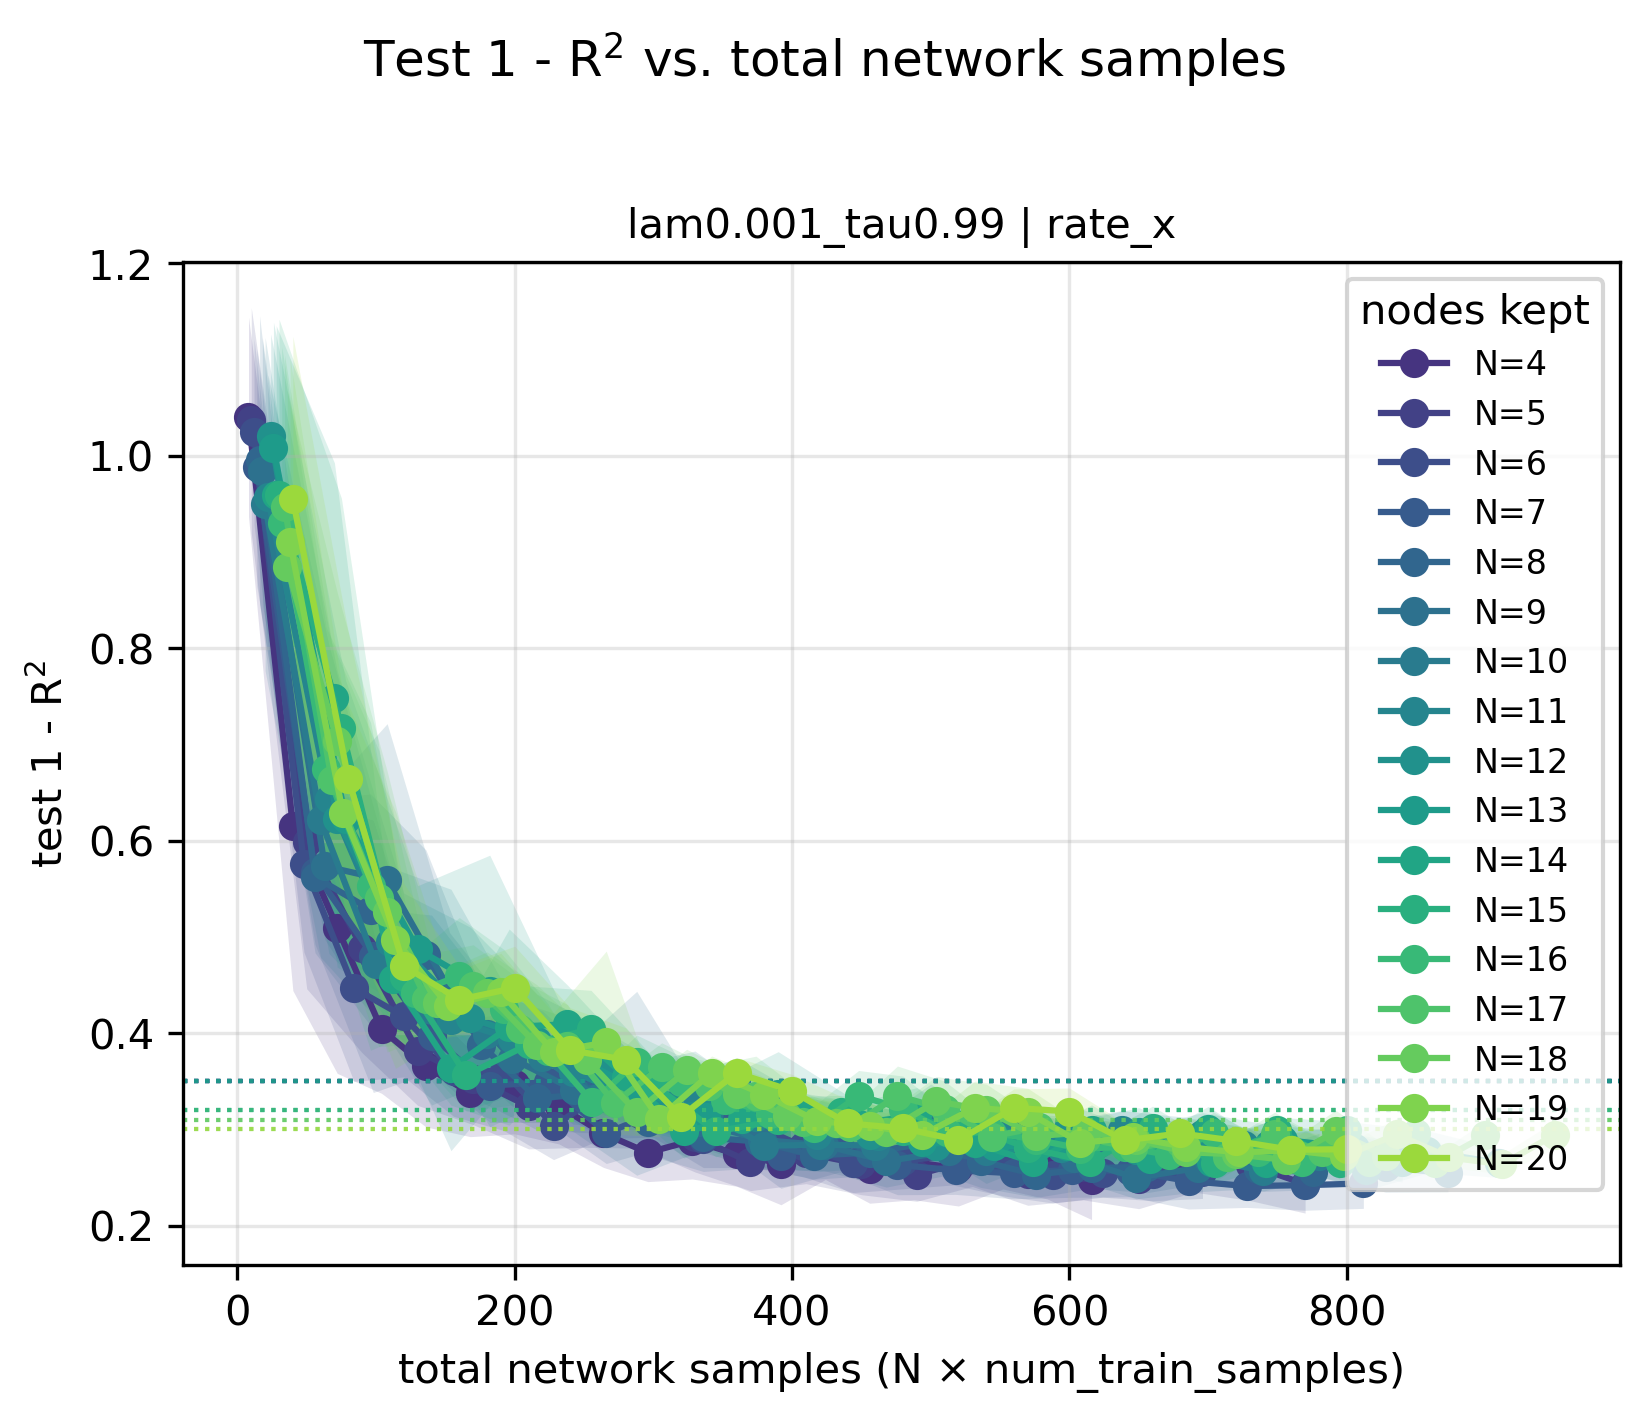

In [4]:
# Plot 1: x = total network samples (num_nodes_keep × num_train_samples), rate_x only.
adj = adj_types[0]
msg = TARGET_MSG_CONFIG

fig, ax = plt.subplots(1, 1, figsize=(5.6, 4.6), sharex=True, sharey=True, dpi=300)
sub = agg_total[(agg_total.adj_type == adj) & (agg_total.msg_config == msg)]
for n in node_counts:
    s = sub[sub.num_nodes_keep == n].sort_values('total_samples')
    if s.empty:
        continue
    ax.plot(s.total_samples, s.mean_one_minus_r2,
            marker='o', label=f'N={n}', color=color_map[n])
    if (s.n_runs > 1).any():
        ax.fill_between(s.total_samples,
                        s.mean_one_minus_r2 - s.std_one_minus_r2,
                        s.mean_one_minus_r2 + s.std_one_minus_r2,
                        color=color_map[n], alpha=0.15, linewidth=0)
    ax.axhline(get_baseline(n), ls='dotted', color=color_map[n], lw=1.0, alpha=0.7)
ax.set_title(f'{adj} | {msg}', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlabel('total network samples (N × num_train_samples)')
ax.set_ylabel('test 1 - R$^2$')
ax.legend(title='nodes kept', loc='best', fontsize=8)
fig.suptitle('Test 1 - R$^2$ vs. total network samples', y=1.02)
fig.tight_layout()
plt.show()


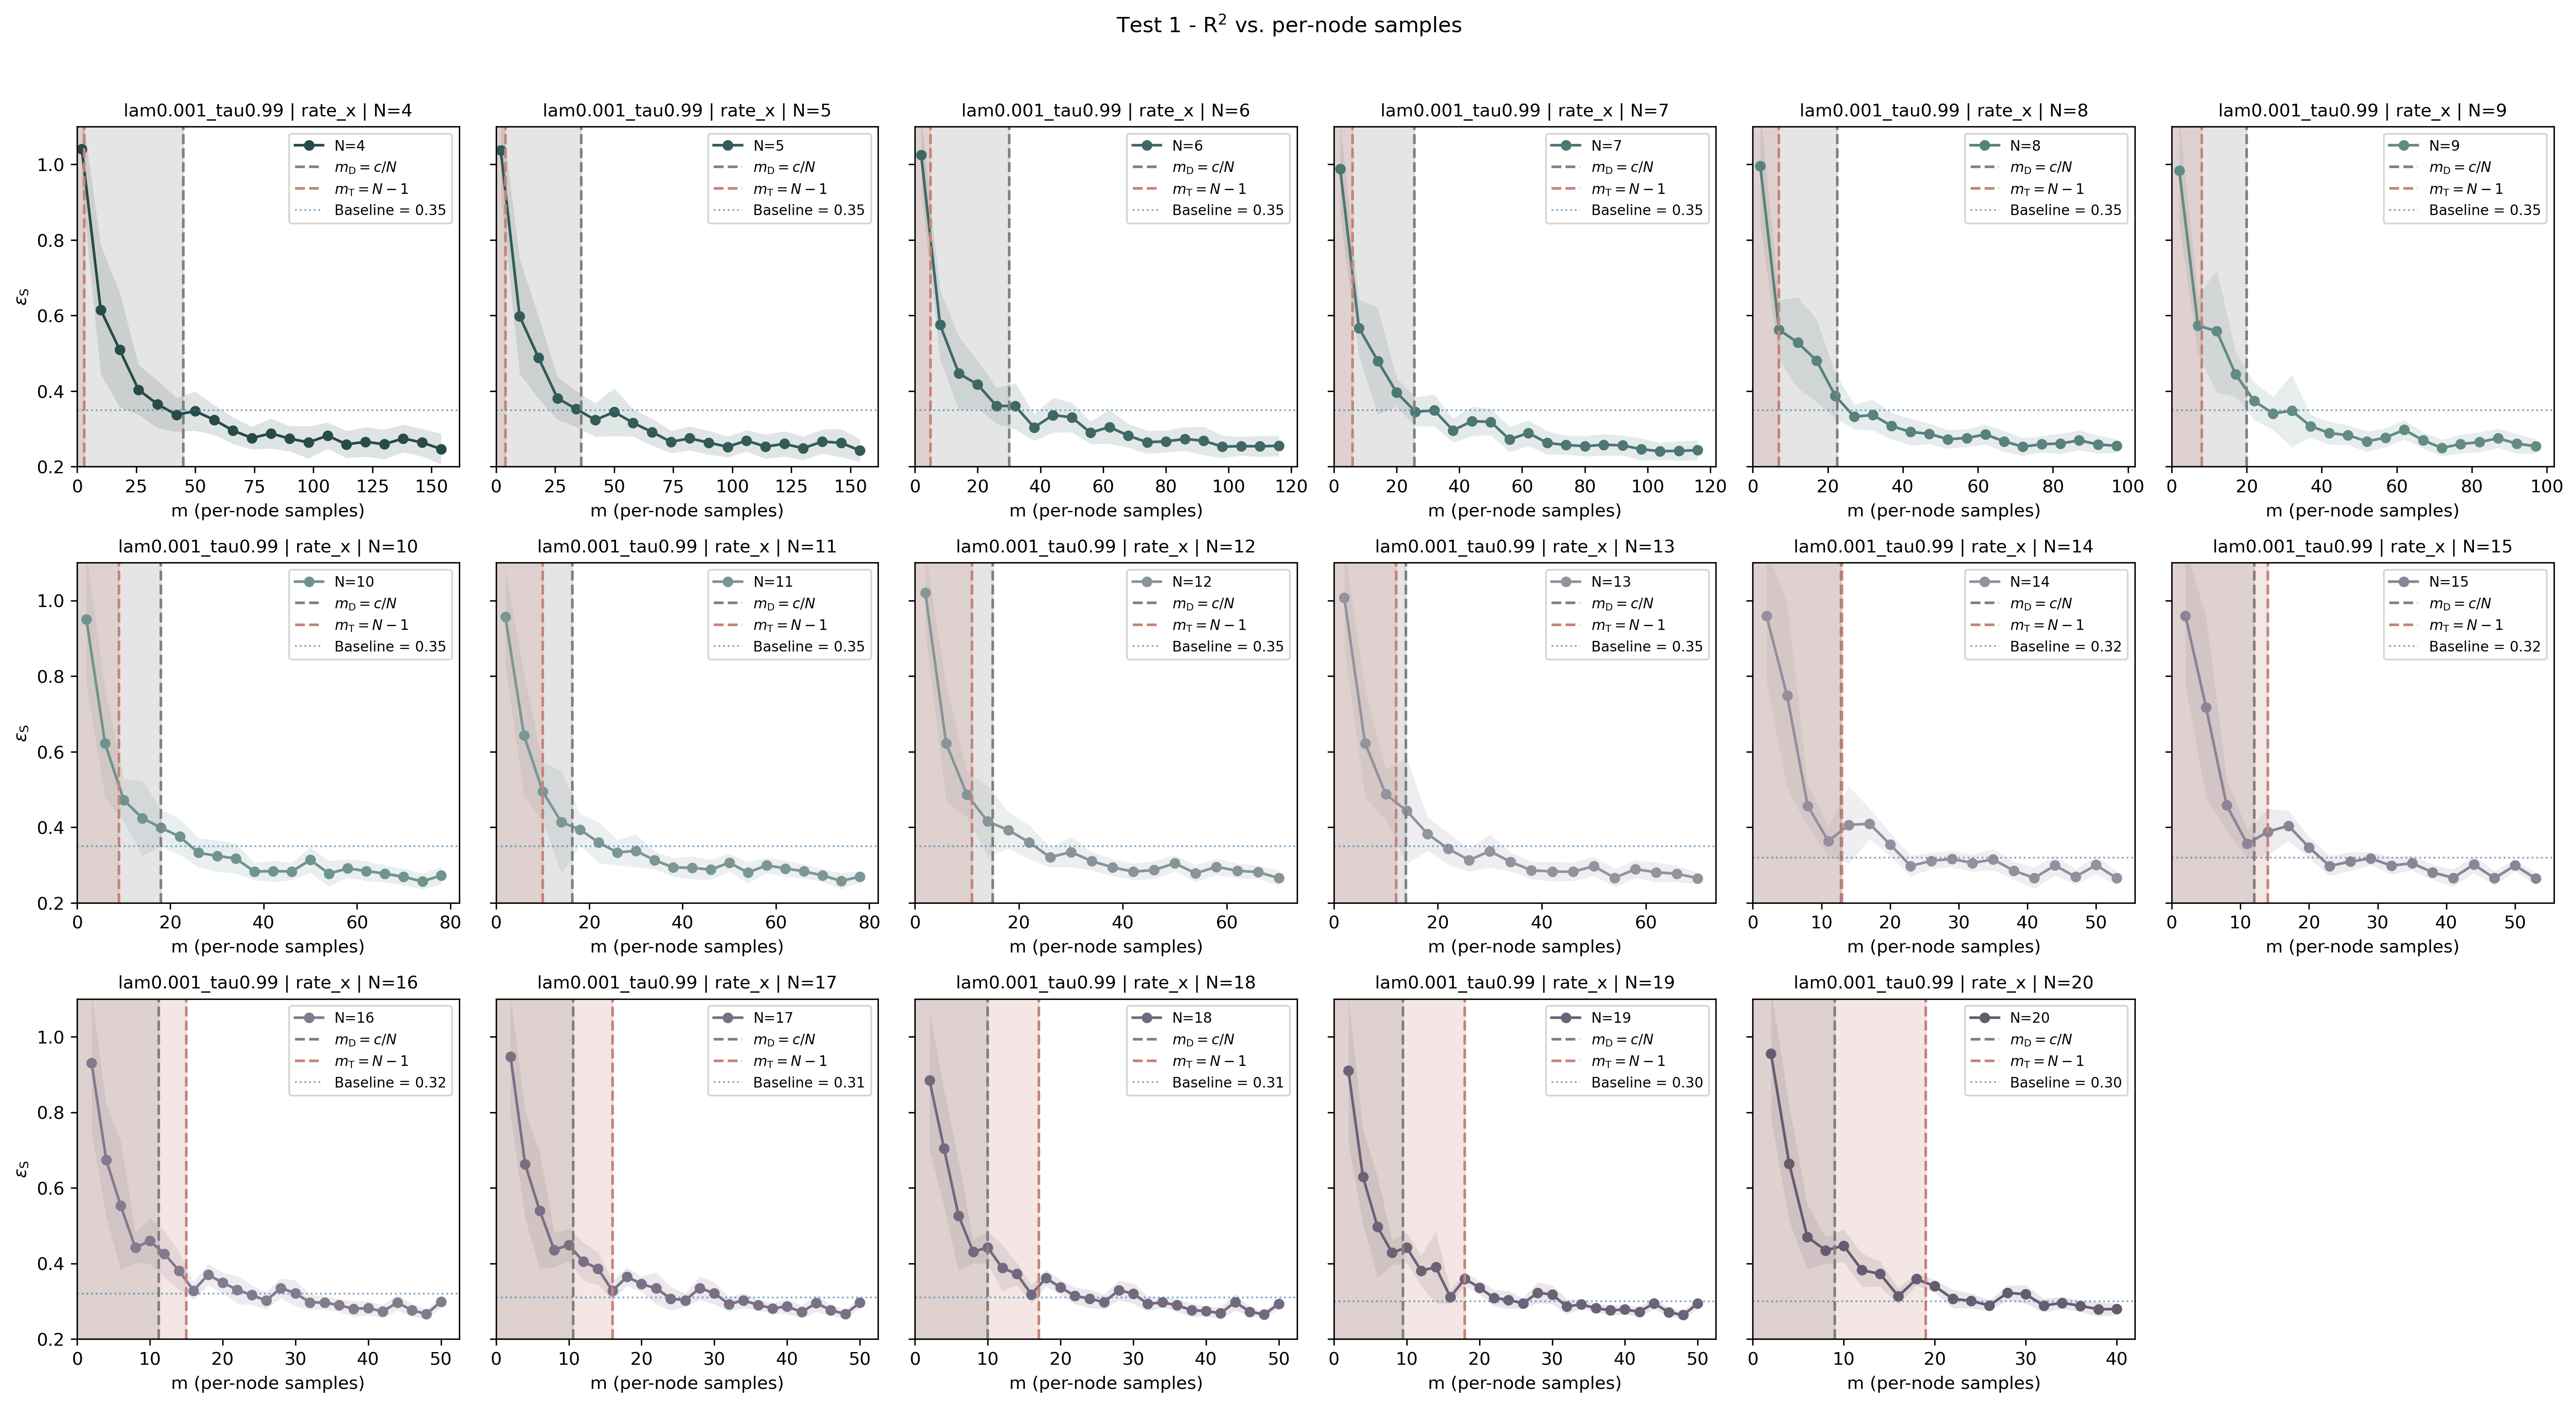

In [6]:
# Plot 2 (with vertical reference lines) for rate_x only.
from matplotlib.colors import LinearSegmentedColormap, to_hex
import math

_node_cmap = LinearSegmentedColormap.from_list(
    'nature_green_purple_clear',
    ['#274B49', '#4E7A76', '#739892', '#9A92A2', '#7C7288', '#655C70']
)

node_to_color = {
    n: to_hex(_node_cmap(i / (len(node_counts) - 1))) if len(node_counts) > 1 else '#6F8F8D'
    for i, n in enumerate(node_counts)
}

def _add_mdyn_line(ax, n):
    x = 180.0 / n
    ax.axvline(x, linestyle='--', color='grey', linewidth=1.5, label='$m_\mathrm{D}=c/N$')

def _add_mdyn_span(ax, n):
    x = 180.0 / n
    ax.axvspan(0, x, color='grey', alpha=0.2)

def _add_mtopo_line(ax, n):
    x = n - 1
    ax.axvline(x, linestyle='--', color='#C6837A', linewidth=1.5, label='$m_\mathrm{T}=N-1$')

def _add_mtopo_span(ax, n):
    x = n - 1
    ax.axvspan(0, x, color='#C6837A', alpha=0.2)

def _add_errorbase_line(ax, baseline):
    ax.axhline(baseline, linestyle='dotted', color='steelblue', linewidth=1.0, alpha=0.7,
               label=f'Baseline = {baseline:.2f}')

def _style_axis(ax):
    ax.set_xlim(left=0.0)
    ax.set_ylim(0.2, 1.1)

ROWS = 3
n_cols = math.ceil(len(node_counts) / ROWS)
row_specs = []
per_row = math.ceil(len(node_counts) / ROWS)
for r in range(ROWS):
    chunk = node_counts[r * per_row:(r + 1) * per_row]
    row_specs.append(chunk)

fig, axes = plt.subplots(ROWS, n_cols,
                         figsize=(3.4 * n_cols, 3.6 * ROWS),
                         sharex=False, sharey=True, squeeze=False, dpi=300)

for r, ns in enumerate(row_specs):
    for c in range(len(ns), n_cols):
        axes[r][c].axis('off')
    for c, n in enumerate(ns):
        ax = axes[r][c]
        s = agg_pernode[(agg_pernode.adj_type == adj)
                        & (agg_pernode.msg_config == TARGET_MSG_CONFIG)
                        & (agg_pernode.num_nodes_keep == n)].sort_values('num_train_samples')
        if not s.empty:
            ax.plot(s.num_train_samples, s.mean_one_minus_r2,
                    marker='o', markersize=5, label=f'N={n}', color=node_to_color[n])
            if (s.n_runs > 1).any():
                ax.fill_between(s.num_train_samples,
                                s.mean_one_minus_r2 - s.std_one_minus_r2,
                                s.mean_one_minus_r2 + s.std_one_minus_r2,
                                color=node_to_color[n], alpha=0.15, linewidth=0)
        baseline = get_baseline(n)
        _add_mdyn_line(ax, n)
        _add_mdyn_span(ax, n)
        _add_mtopo_line(ax, n)
        _add_mtopo_span(ax, n)
        _style_axis(ax)
        _add_errorbase_line(ax, baseline)
        ax.set_title(f'{adj} | {TARGET_MSG_CONFIG} | N={n}', fontsize=10)
        ax.set_xlabel('m (per-node samples)')
        if c == 0:
            ax.set_ylabel('$\epsilon_\mathrm{S}$')
        ax.legend(loc='best', fontsize=8)

fig.suptitle('Test 1 - R$^2$ vs. per-node samples', y=1.02)
fig.tight_layout()
plt.show()


### Phase diagram for chickenpox inference data

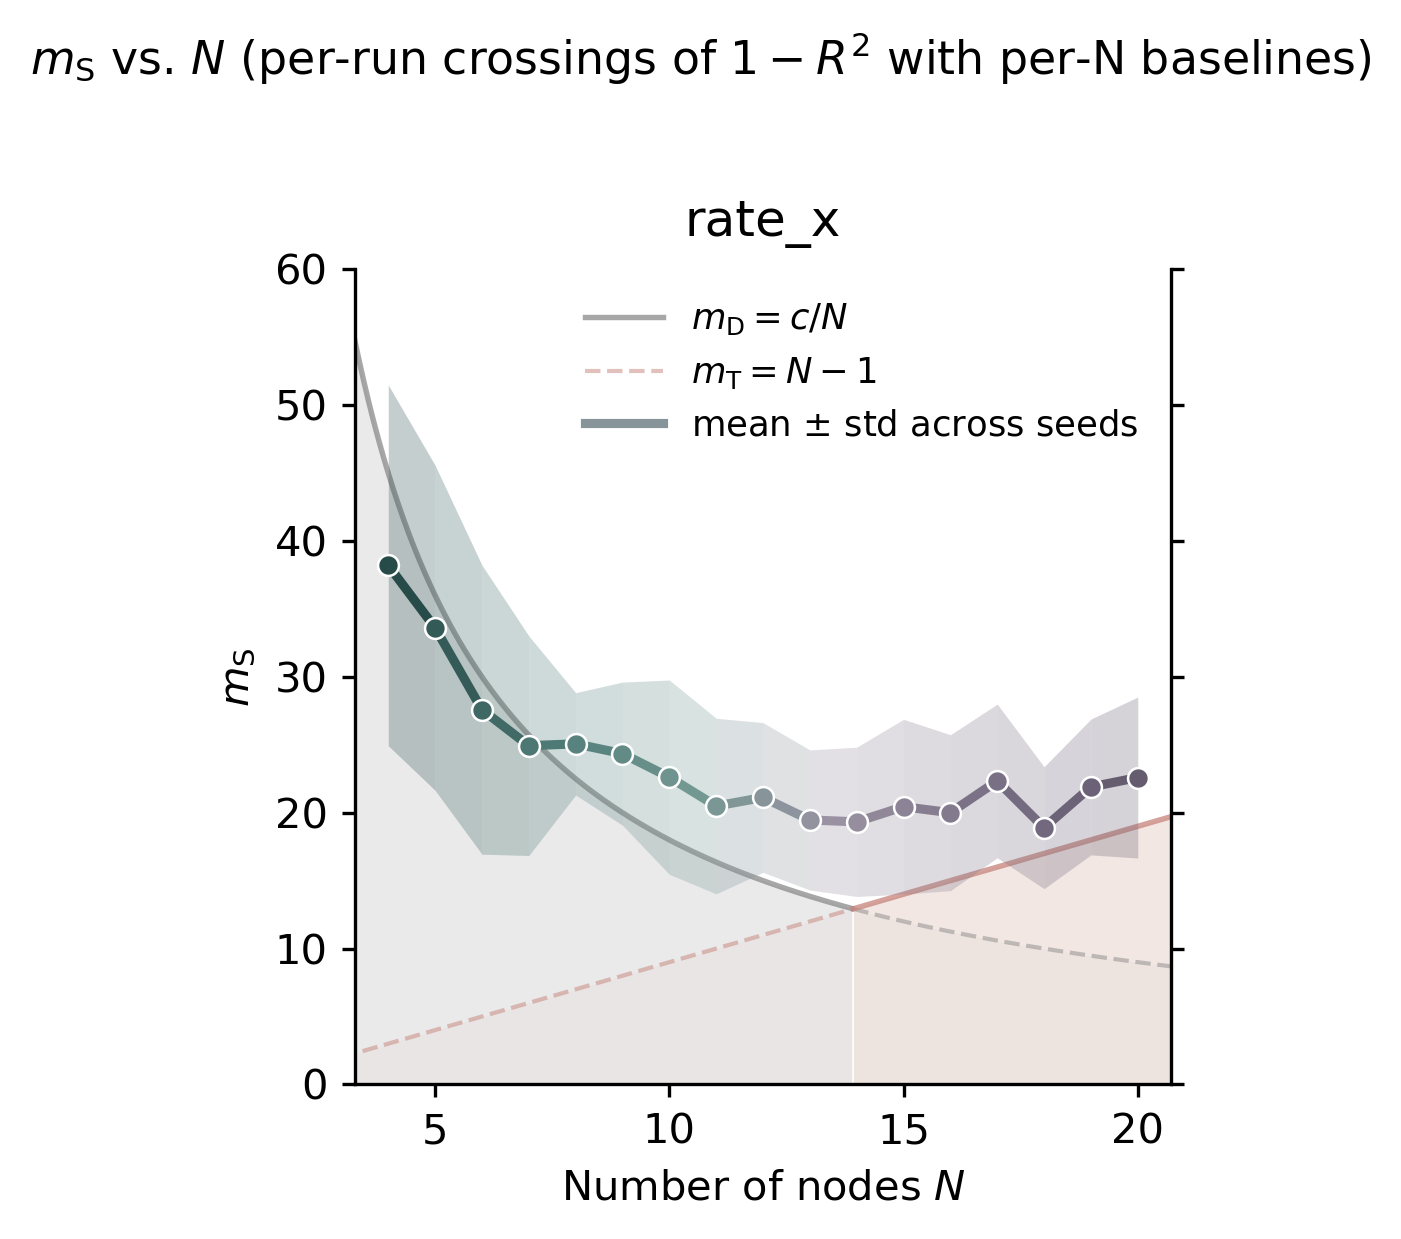

In [7]:
from matplotlib.colors import LinearSegmentedColormap, to_hex, to_rgba
from matplotlib.collections import LineCollection
from scipy.optimize import brentq
import numpy as np

seeds_sorted = sorted(df.seed.unique())

def epsilon_S_crossing(xs, ys, y0):
    """Linear-interp x at which y(x) first crosses y0; nan if no crossing."""
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    if len(xs) < 2:
        return np.nan
    for i in range(len(xs) - 1):
        y1, y2 = ys[i], ys[i + 1]
        if (y1 - y0) * (y2 - y0) <= 0 and y1 != y2:
            t = (y0 - y1) / (y2 - y1)
            return round(float(xs[i] + t * (xs[i + 1] - xs[i])), 2)
    return np.nan

fig, axes = plt.subplots(1, len(msg_configs),
                         figsize=(4.0 * len(msg_configs), 4.0),
                         sharey=False, squeeze=False, dpi=300)

COLORS = {
    "fill_inv":    "#D9D9D9",
    "line_inv":    "#8A8A8A",
    "fill_diag":   "#E8D5CD",
    "line_diag":   "#C6837A",
}

node_cmap = LinearSegmentedColormap.from_list(
    "nature_green_purple_clear",
    ["#274B49", "#4E7A76", "#739892", "#9A92A2", "#7C7288", "#655C70"]
)

node_to_color = {
    n: to_hex(node_cmap(i / (len(node_counts) - 1))) if len(node_counts) > 1 else "#6F8F8D"
    for i, n in enumerate(node_counts)
}

nc = np.array(node_counts, dtype=float)

# Crossing point of 180/x and (x-1)
x_cross_pt = brentq(lambda x: 180.0 / x - (x - 1), 2, 30)

for k, msg in enumerate(msg_configs):
    ax = axes[0][k]

    grouped = {}
    for n in node_counts:
        y_baseline = get_baseline(n)
        grouped[n] = []
        for seed in seeds_sorted:
            s = df[
                (df.adj_type == adj) &
                (df.msg_config == msg) &
                (df.num_nodes_keep == n) &
                (df.seed == seed)
            ].sort_values("num_train_samples")
            if s.empty:
                continue
            x_cross = epsilon_S_crossing(
                s.num_train_samples.values,
                s.one_minus_r2.values,
                y_baseline
            )
            if np.isfinite(x_cross):
                grouped[n].append(x_cross)

    y_points = np.concatenate(
        [np.asarray(v, dtype=float) for v in grouped.values() if len(v)]
    ) if any(len(v) for v in grouped.values()) else np.array([])

    # ---- Reference curves with style/alpha flip at crossing point (same as last fig) ----
    xref = np.linspace(max(nc[0] - 1, 1), nc[-1] + 1, 500)
    mask_left  = xref <= x_cross_pt
    mask_right = xref >  x_cross_pt

    y_inv  = 180.0 / xref
    y_diag = xref - 1

    ax.fill_between(xref[mask_left],  0, y_inv[mask_left],
                    color=COLORS["fill_inv"],  alpha=0.55, linewidth=0, zorder=0)
    ax.fill_between(xref[mask_right], 0, y_inv[mask_right],
                    color=COLORS["fill_inv"],  alpha=0.20, linewidth=0, zorder=0)
    ax.fill_between(xref[mask_left],  0, y_diag[mask_left],
                    color=COLORS["fill_diag"], alpha=0.20, linewidth=0, zorder=0)
    ax.fill_between(xref[mask_right], 0, y_diag[mask_right],
                    color=COLORS["fill_diag"], alpha=0.55, linewidth=0, zorder=0)

    ax.plot(xref[mask_left],  y_inv[mask_left],  color=COLORS["line_inv"], lw=1.3,
            ls='-',  alpha=0.75, zorder=1, label=r"$m_\mathrm{D}=c/N$")
    ax.plot(xref[mask_right], y_inv[mask_right], color=COLORS["line_inv"], lw=1,
            ls='--', alpha=0.5, zorder=1)

    ax.plot(xref[mask_left],  y_diag[mask_left],  color=COLORS["line_diag"], lw=1,
            ls='--', alpha=0.5, zorder=1, label=r"$m_\mathrm{T}=N-1$")
    ax.plot(xref[mask_right], y_diag[mask_right], color=COLORS["line_diag"], lw=1.3,
            ls='-',  alpha=0.75, zorder=1)

    # mean +/- std per N
    n_mu, y_mu, y_lo, y_hi = [], [], [], []
    for n in node_counts:
        vals = np.asarray(grouped.get(n, []), dtype=float)
        if len(vals) == 0:
            continue
        mu = float(np.mean(vals))
        sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        n_mu.append(n)
        y_mu.append(mu)
        y_lo.append(mu - sd)
        y_hi.append(mu + sd)

    n_mu = np.asarray(n_mu, dtype=float)
    y_mu = np.asarray(y_mu, dtype=float)
    y_lo = np.asarray(y_lo, dtype=float)
    y_hi = np.asarray(y_hi, dtype=float)

    if len(n_mu) > 0:
        # --- gradient shadow: fill each segment between consecutive N with cmap color ---
        for i in range(len(n_mu) - 1):
            t = (i + 0.5) / max(len(n_mu) - 1, 1)
            seg_color = node_cmap(t)
            ax.fill_between(
                n_mu[i:i+2], y_lo[i:i+2], y_hi[i:i+2],
                color=seg_color, alpha=0.28, linewidth=0, zorder=2
            )

        # --- gradient mean line: LineCollection, color per segment ---
        pts = np.column_stack([n_mu, y_mu]).reshape(-1, 1, 2)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
        seg_t = np.linspace(0, 1, max(len(n_mu) - 1, 1))
        seg_colors = [node_cmap(t) for t in seg_t]
        lc = LineCollection(segs, colors=seg_colors, linewidths=2.2, zorder=4)
        ax.add_collection(lc)
        # marker points with matching per-N color
        for xi, yi, n in zip(n_mu, y_mu, node_counts if len(node_counts)==len(n_mu) else n_mu):
            ax.plot(xi, yi, marker="o", markersize=5.0,
                    color=node_to_color.get(int(xi), node_cmap(0.5)),
                    markeredgecolor="white", markeredgewidth=0.6, zorder=5)
        # proxy for legend
        ax.plot([], [], color=node_cmap(0.5), linewidth=2.2,
                label="mean $\pm$ std across seeds")

    ax.set_title(msg, pad=8)
    ax.set_xlabel(r"Number of nodes $N$")
    ax.set_ylabel(r"$m_\mathrm{S}$")
    ax.set_xlim(nc[0] - 0.7, nc[-1] + 0.7)
    ax.set_ylim(0, 60)

    ax.set_xticks([5, 10, 15, 20])
    ax.set_box_aspect(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["right"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(direction="out", length=3.2, width=0.8)
    ax.tick_params(axis='y', which='both', right=True)

    if k == 0:
        ax.legend(
            loc="upper right",
            frameon=False,
            fontsize=8.5,
            handlelength=2.2
        )

fig.suptitle(
    r"$m_\mathrm{S}$ vs. $N$ (per-run crossings of $1-R^2$ with per-N baselines)",
    y=1.02, fontsize=11
)
fig.tight_layout()
# fig.savefig(os.path.join(BASE_DIR, f"m_S_per_run_vs_N_mean_std_diff_thresh_run{len(sorted(df.seed.unique()))}.pdf"), bbox_inches="tight")
plt.show()


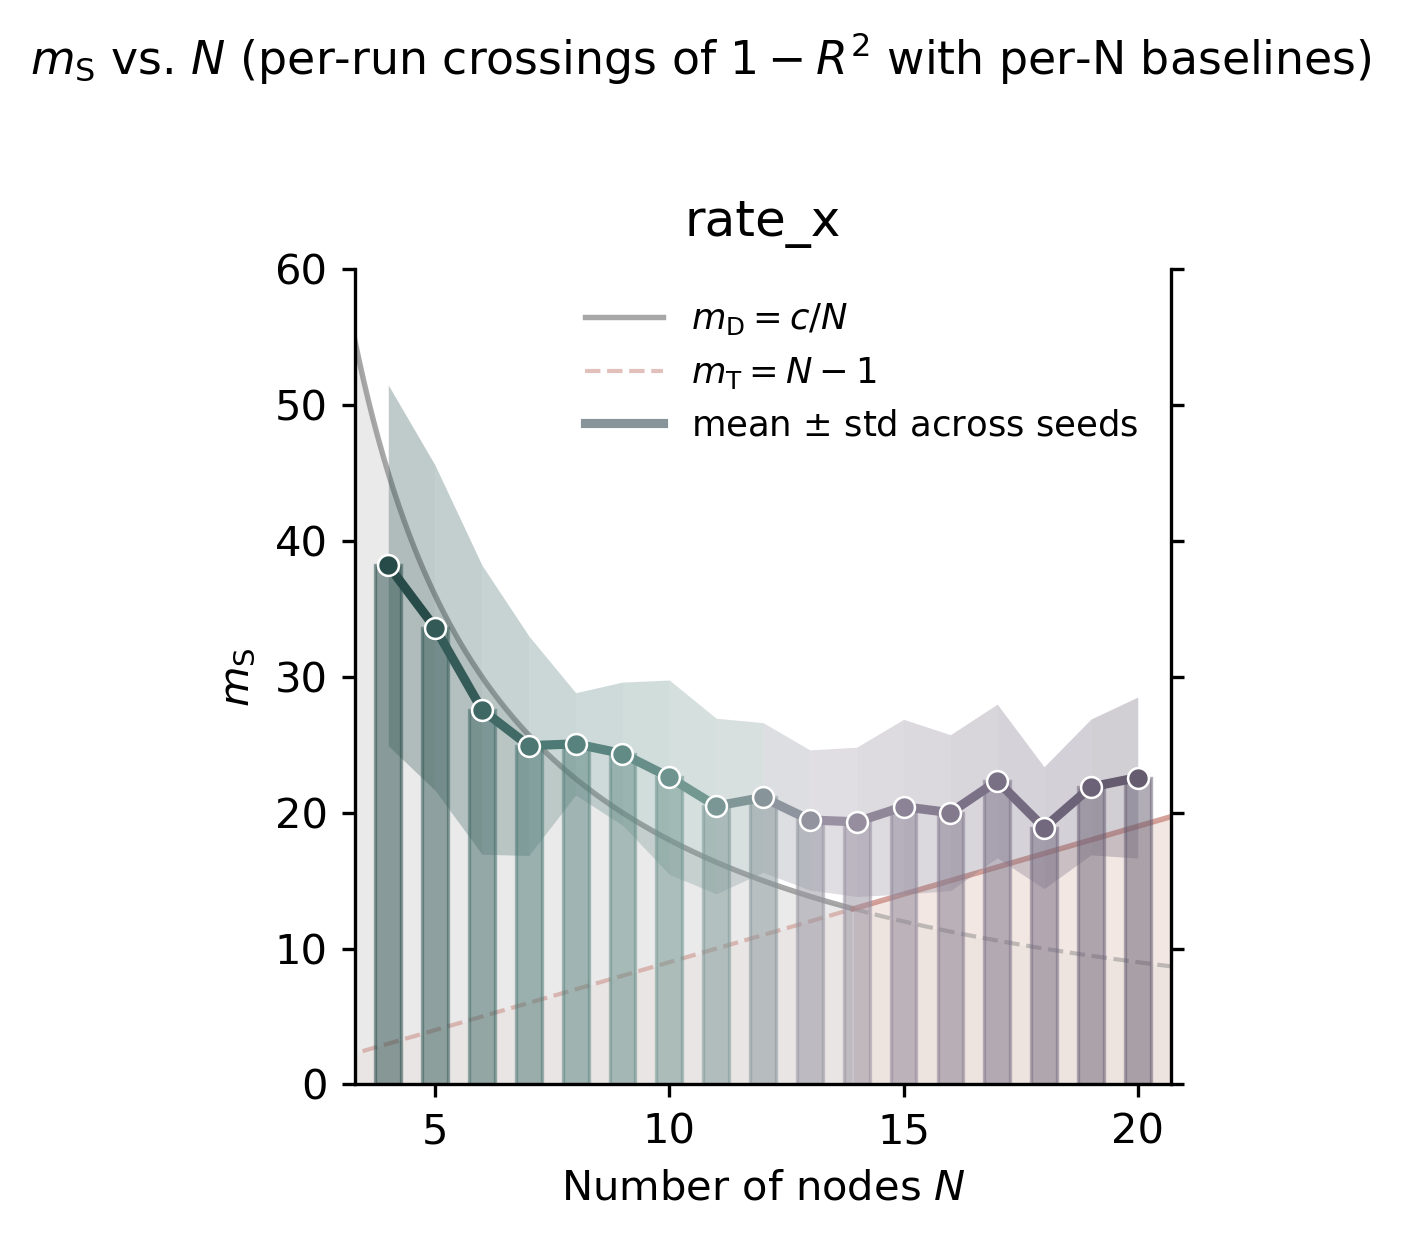

In [8]:
from matplotlib.colors import LinearSegmentedColormap, to_hex, to_rgba
from matplotlib.collections import LineCollection
from scipy.optimize import brentq
import numpy as np

seeds_sorted = sorted(df.seed.unique())

def epsilon_S_crossing(xs, ys, y0):
    """Linear-interp x at which y(x) first crosses y0; nan if no crossing."""
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    if len(xs) < 2:
        return np.nan
    for i in range(len(xs) - 1):
        y1, y2 = ys[i], ys[i + 1]
        if (y1 - y0) * (y2 - y0) <= 0 and y1 != y2:
            t = (y0 - y1) / (y2 - y1)
            return round(float(xs[i] + t * (xs[i + 1] - xs[i])), 2)
    return np.nan

fig, axes = plt.subplots(1, len(msg_configs),
                         figsize=(4.0 * len(msg_configs), 4.0),
                         sharey=False, squeeze=False, dpi=300)

COLORS = {
    "fill_inv":    "#D9D9D9",
    "line_inv":    "#8A8A8A",
    "fill_diag":   "#E8D5CD",
    "line_diag":   "#C6837A",
}

node_cmap = LinearSegmentedColormap.from_list(
    "nature_green_purple_clear",
    ["#274B49", "#4E7A76", "#739892", "#9A92A2", "#7C7288", "#655C70"]
)

node_to_color = {
    n: to_hex(node_cmap(i / (len(node_counts) - 1))) if len(node_counts) > 1 else "#6F8F8D"
    for i, n in enumerate(node_counts)
}

nc = np.array(node_counts, dtype=float)
min_gap = float(np.min(np.diff(nc))) if len(nc) > 1 else 2.0
BAR_WIDTH = min_gap * 0.55

# Crossing point of 180/x and (x-1)
x_cross_pt = brentq(lambda x: 180.0 / x - (x - 1), 2, 30)

for k, msg in enumerate(msg_configs):
    ax = axes[0][k]

    grouped = {}
    for n in node_counts:
        y_baseline = get_baseline(n)
        grouped[n] = []
        for seed in seeds_sorted:
            s = df[
                (df.adj_type == adj) &
                (df.msg_config == msg) &
                (df.num_nodes_keep == n) &
                (df.seed == seed)
            ].sort_values("num_train_samples")
            if s.empty:
                continue
            x_cross = epsilon_S_crossing(
                s.num_train_samples.values,
                s.one_minus_r2.values,
                y_baseline
            )
            if np.isfinite(x_cross):
                grouped[n].append(x_cross)

    y_points = np.concatenate(
        [np.asarray(v, dtype=float) for v in grouped.values() if len(v)]
    ) if any(len(v) for v in grouped.values()) else np.array([])

    # ---- Reference curves with style/alpha flip at crossing point (same as last fig) ----
    xref = np.linspace(max(nc[0] - 1, 1), nc[-1] + 1, 500)
    mask_left  = xref <= x_cross_pt
    mask_right = xref >  x_cross_pt

    y_inv  = 180.0 / xref
    y_diag = xref - 1

    ax.fill_between(xref[mask_left],  0, y_inv[mask_left],
                    color=COLORS["fill_inv"],  alpha=0.55, linewidth=0, zorder=0)
    ax.fill_between(xref[mask_right], 0, y_inv[mask_right],
                    color=COLORS["fill_inv"],  alpha=0.20, linewidth=0, zorder=0)
    ax.fill_between(xref[mask_left],  0, y_diag[mask_left],
                    color=COLORS["fill_diag"], alpha=0.20, linewidth=0, zorder=0)
    ax.fill_between(xref[mask_right], 0, y_diag[mask_right],
                    color=COLORS["fill_diag"], alpha=0.55, linewidth=0, zorder=0)

    ax.plot(xref[mask_left],  y_inv[mask_left],  color=COLORS["line_inv"], lw=1.3,
            ls='-',  alpha=0.75, zorder=1, label=r"$m_\mathrm{D}=c/N$")
    ax.plot(xref[mask_right], y_inv[mask_right], color=COLORS["line_inv"], lw=1,
            ls='--', alpha=0.5, zorder=1)

    ax.plot(xref[mask_left],  y_diag[mask_left],  color=COLORS["line_diag"], lw=1,
            ls='--', alpha=0.5, zorder=1, label=r"$m_\mathrm{T}=N-1$")
    ax.plot(xref[mask_right], y_diag[mask_right], color=COLORS["line_diag"], lw=1.3,
            ls='-',  alpha=0.75, zorder=1)

    # mean +/- std per N
    n_mu, y_mu, y_lo, y_hi = [], [], [], []
    for n in node_counts:
        vals = np.asarray(grouped.get(n, []), dtype=float)
        if len(vals) == 0:
            continue
        mu = float(np.mean(vals))
        sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        n_mu.append(n)
        y_mu.append(mu)
        y_lo.append(mu - sd)
        y_hi.append(mu + sd)

    n_mu = np.asarray(n_mu, dtype=float)
    y_mu = np.asarray(y_mu, dtype=float)
    y_lo = np.asarray(y_lo, dtype=float)
    y_hi = np.asarray(y_hi, dtype=float)

    # --- per-node bars at mean value (no errorbar, no scatter) ---
    for n_val, mu_val in zip(n_mu, y_mu):
        ax.bar(n_val, mu_val, width=BAR_WIDTH,
               color=node_to_color[int(n_val)], alpha=0.5,
               edgecolor=node_to_color[int(n_val)], linewidth=0.8, zorder=1.8)

    if len(n_mu) > 0:
        # --- gradient shadow: fill each segment between consecutive N with cmap color ---
        for i in range(len(n_mu) - 1):
            t = (i + 0.5) / max(len(n_mu) - 1, 1)
            seg_color = node_cmap(t)
            ax.fill_between(
                n_mu[i:i+2], y_lo[i:i+2], y_hi[i:i+2],
                color=seg_color, alpha=0.3, linewidth=0, zorder=2
            )

        # --- gradient mean line: LineCollection, color per segment ---
        pts = np.column_stack([n_mu, y_mu]).reshape(-1, 1, 2)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
        seg_t = np.linspace(0, 1, max(len(n_mu) - 1, 1))
        seg_colors = [node_cmap(t) for t in seg_t]
        lc = LineCollection(segs, colors=seg_colors, linewidths=2.2, zorder=4)
        ax.add_collection(lc)
        # marker points with matching per-N color
        for xi, yi, n in zip(n_mu, y_mu, node_counts if len(node_counts)==len(n_mu) else n_mu):
            ax.plot(xi, yi, marker="o", markersize=5.0,
                    color=node_to_color.get(int(xi), node_cmap(0.5)),
                    markeredgecolor="white", markeredgewidth=0.6, zorder=5)
        # proxy for legend
        ax.plot([], [], color=node_cmap(0.5), linewidth=2.2,
                label="mean $\pm$ std across seeds")

    ax.set_title(msg, pad=8)
    ax.set_xlabel(r"Number of nodes $N$")
    ax.set_ylabel(r"$m_\mathrm{S}$")
    ax.set_xlim(nc[0] - 0.7, nc[-1] + 0.7)
    ax.set_ylim(0, 60)

    ax.set_xticks([5, 10, 15, 20])
    ax.set_box_aspect(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["right"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(direction="out", length=3.2, width=0.8)
    ax.tick_params(axis='y', which='both', right=True)

    if k == 0:
        ax.legend(
            loc="upper right",
            frameon=False,
            fontsize=8.5,
            handlelength=2.2
        )

fig.suptitle(
    r"$m_\mathrm{S}$ vs. $N$ (per-run crossings of $1-R^2$ with per-N baselines)",
    y=1.02, fontsize=11
)
fig.tight_layout()
# fig.savefig(os.path.join(BASE_DIR, f"m_S_per_run_vs_N_mean_std_diff_thresh_bar_run{len(sorted(df.seed.unique()))}.pdf"), bbox_inches="tight")
plt.show()